# 步骤 01 · 把数据读进来，画出波形

**这一节的产出：图 1 —— 四种状态的时域波形对比。**

## 怎么用这个笔记本

每个灰框叫一个**格子**（cell）。点一下格子，按 `Shift + Enter`，它就运行，结果显示在下面。

**必须从上往下依次运行**，因为后面的格子要用前面格子算出来的变量。要是搞乱了，菜单 `Run → Restart Kernel and Run All Cells` 从头来一遍。

> **Kernel（内核）**：真正跑你代码的那个 Python 进程。笔记本本身只是个界面。Restart Kernel = 把 Python 重启，所有变量清空。

## 这一节想让你看到什么

四条振动曲线摆在一起：一条来自健康轴承，三条来自坏的。

**其中一条你能用眼睛直接诊断出来，另外两条不能。** 搞清楚"为什么有的行有的不行"，就是这一节的全部意义 —— 它是后面每一步的理由。

---
## 1. 准备工作

下面这段代码干三件事：告诉 Python 去哪儿找我们自己写的模块、把要用的工具箱拿进来、设定画图的默认样式。

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# 让 Python 能找到 src/ 下我们自己写的 cwru_io.py
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import cwru_io

DATA = ROOT / "data"
FIGURES = ROOT / "figures"

print("项目根目录:", ROOT)
print("数据目录存在:", DATA.exists())

项目根目录: D:\废弃学习资料\老子有用\文书文件\bearing-diagnosis
数据目录存在: True


**逐行解释：**

| 写法 | 意思 |
|---|---|
| `import numpy as np` | 把 NumPy 这个库拿进来，起个短名叫 `np`。相当于 C++ 的 `#include` + `using`。 |
| `np` | **NumPy**：Python 的数组运算库。Python 原生的 list 做数学运算慢得没法用，NumPy 的数组底层是 C 写的，一行 `a * 2` 就把整个数组每个元素翻倍。你会一直用它。 |
| `plt` | **Matplotlib**：画图库。`plt` 是它的"快捷画图"接口。 |
| `Path` | 路径对象。比手写 `"data\x.mat"` 好，跨平台、能直接 `/` 拼接。 |
| `sys.path.insert(...)` | Python 找模块的搜索路径列表。把 `src/` 加进去，下一行的 `import cwru_io` 才能成功。 |

`ROOT` 那一行是为了不管你从项目根目录还是从 `notebooks/` 里启动 Jupyter，路径都对。

---
## 2. 读数据

`cwru_io` 是我们自己写的那个"开罐器"。它把一个 `.mat` 文件变成一个 `Signal` 对象。

注意正常那个文件用的是 `load_baseline` 而不是 `load` —— 因为它是 48 kHz 采样、而且文件里没存转速，需要特殊处理（详见 `data/FILES.md`）。

In [2]:
normal = cwru_io.load_baseline(DATA / "normal_1hp_98.mat",    name="Healthy")
outer  = cwru_io.load(DATA / "OR007at6_1hp_131.mat", name="Outer race 0.007in")
inner  = cwru_io.load(DATA / "IR007_1hp_106.mat",    name="Inner race 0.007in")
ball   = cwru_io.load(DATA / "B007_1hp_119.mat",     name="Ball 0.007in")

signals = [normal, outer, inner, ball]

for s in signals:
    print(s)

Signal('Healthy', 120976 samples, 10.08 s, 1772 rpm)
Signal('Outer race 0.007in', 122426 samples, 10.20 s, 1773 rpm)
Signal('Inner race 0.007in', 121991 samples, 10.17 s, 1772 rpm)
Signal('Ball 0.007in', 121410 samples, 10.12 s, 1772 rpm)


每个 `Signal` 里存着：

- `s.x` —— 振动数据本身，一个很长的 NumPy 数组（12 万个数）
- `s.fs` —— 采样率，12000（每秒记 12000 个数）
- `s.rpm` —— 转速，约 1772 转/分
- `s.n` —— 转速换算成"每秒几圈"：1772 / 60 ≈ 29.5
- `s.fault_freqs()` —— 按这个转速算出的三个理论故障频率

试试下面这格，看看数据长什么样。

In [3]:
print("outer.x 的类型:", type(outer.x))
print("长度:", len(outer.x))
print("前 8 个数:", outer.x[:8])
print()
print("这个文件的理论故障频率 (Hz):")
for k, v in outer.fault_freqs().items():
    print(f"  {k}: {v:.1f}")

outer.x 的类型: <class 'numpy.ndarray'>
长度: 122426
前 8 个数: [-0.11045589  0.21563263  0.0799993  -0.31796677  0.02314701  0.17746038
  0.0998976  -0.23187615]

这个文件的理论故障频率 (Hz):
  BPFO: 105.9
  BPFI: 160.0
  BSF: 139.3
  FTF: 11.8


> **Hz（赫兹）** 就是"每秒多少次"。`BPFO: 105.9` 的意思是：如果外圈上有坑，滚珠每秒会碾过它 105.9 次。

`outer.x[:8]` 这个写法叫**切片**（slice），取数组的前 8 个元素。Python 的切片是 `[起点:终点]`，**不含终点**，和 C++ 的迭代器区间一个道理。

---
## 3. 什么是"波形"

传感器每隔 1/12000 秒记一个数，记 10 秒，就是 12 万个数。

把这些数画出来：**横轴是时间，纵轴是那一瞬间外壳抖动的加速度**。这张图就叫**时域波形**（time-domain waveform）。"时域"的意思就是"横轴是时间"。

10 秒 × 12000 = 12 万个点，全画出来会糊成一团黑。所以只取**前 0.2 秒**，也就是前 2400 个点。0.2 秒里轴转了约 6 圈，滚珠碾过外圈上同一点约 21 次 —— 足够看出节奏，又不至于挤成一坨。

In [4]:
DURATION = 0.2                      # 秒
N = int(DURATION * cwru_io.FS)      # 0.2 * 12000 = 2400 个点
t = np.arange(N) / cwru_io.FS       # 时间轴: 0, 1/12000, 2/12000, ...

print(f"每条曲线画 {N} 个点，横轴从 {t[0]:.4f} 秒到 {t[-1]:.4f} 秒")

每条曲线画 2400 个点，横轴从 0.0000 秒到 0.1999 秒


`np.arange(N)` 生成 `[0, 1, 2, ..., N-1]`。除以 12000 就把"第几个采样点"换算成"第几秒"。

这是 NumPy 的**向量化**：`np.arange(N) / 12000` 一次把 2400 个数全除了，不用写循环。你写 C 的时候那是个 `for`，这里是一行。

---
## 4. 画图 1

下面是这一节的正题。代码稍长，但结构很简单：开一张四行的画布，每行画一条曲线。

**注意 `sharey=True` 这个参数** —— 它强制四个子图用同一个纵轴刻度。不加的话 Matplotlib 会给每个子图各自缩放，健康的那条被放大到和故障的一样高，**整张对比图就是假的**。这是画对比图最容易犯的错。

图上的文字全用英文，因为最终报告是英文的，而且省得配中文字体。

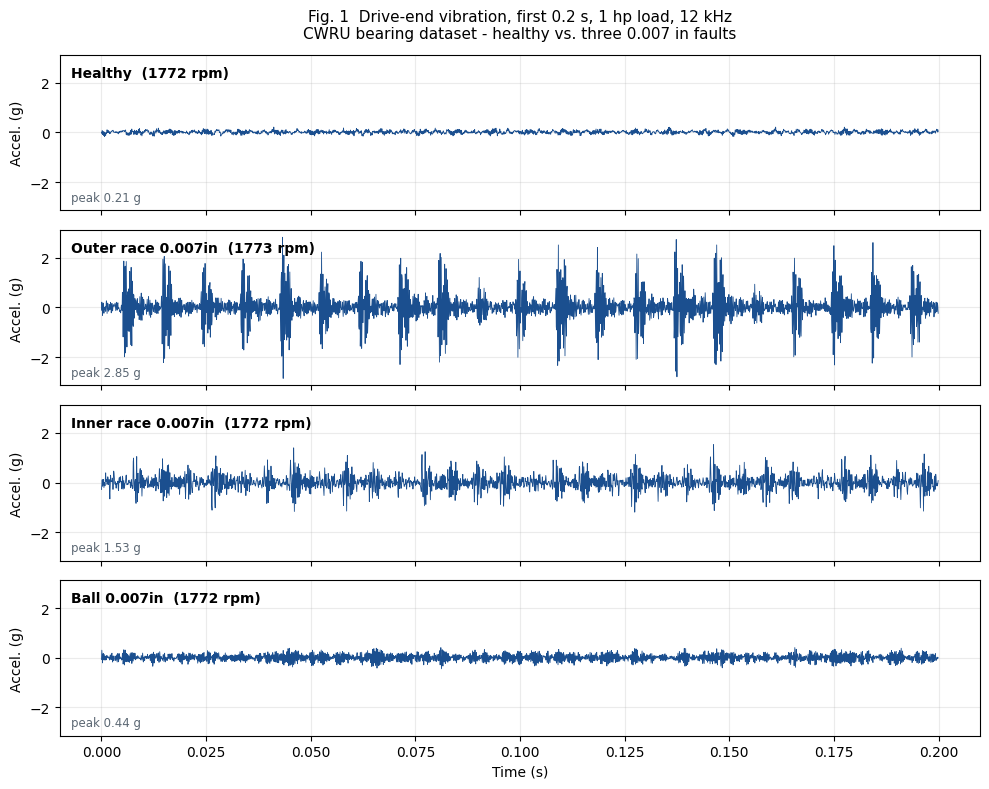

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True, sharey=True)

for ax, s in zip(axes, signals):
    ax.plot(t, s.x[:N], linewidth=0.6, color="#1B4F8F")
    ax.set_ylabel("Accel. (g)")
    ax.grid(alpha=0.25)
    # 在每个子图左上角标注是哪种状态、峰值多大
    ax.text(0.012, 0.86, f"{s.name}  ({s.rpm:.0f} rpm)",
            transform=ax.transAxes, fontsize=10, fontweight="bold")
    ax.text(0.012, 0.06, f"peak {np.abs(s.x[:N]).max():.2f} g",
            transform=ax.transAxes, fontsize=8.5, color="#5B6773")

axes[-1].set_xlabel("Time (s)")
axes[0].set_title(
    "Fig. 1  Drive-end vibration, first 0.2 s, 1 hp load, 12 kHz\n"
    "CWRU bearing dataset - healthy vs. three 0.007 in faults",
    fontsize=11, pad=12)

fig.tight_layout()
plt.show()

**这段代码里的 Matplotlib 概念：**

| 名词 | 是什么 |
|---|---|
| `fig` | **Figure**，整张画布 |
| `ax` / `axes` | **Axes**，画布上的一个子图（一套坐标轴）。`subplots(4,1)` 就是竖着切 4 块 |
| `ax.plot(x, y)` | 在这个子图上画一条线 |
| `transform=ax.transAxes` | 标注位置按"子图的相对位置"算：`(0, 0)` 是左下角，`(1, 1)` 是右上角。这样换数据也不用改坐标 |
| `zip(axes, signals)` | 把两个列表配对：第 1 个子图配第 1 个信号，第 2 配第 2……相当于同时遍历两个数组 |
| `tight_layout()` | 自动调整间距，免得标签互相压 |

---
## 5. 你应该看到什么

盯着图看，从上往下确认：

**① Healthy（健康）—— 一条细带子。** 峰值只有 0.21 g，整条线几乎压在零轴上，看不出任何结构。这就是好轴承该有的样子。

**② Outer race（外圈）—— 一簇一簇的爆发，间隔肉眼可见地均匀。** 峰值 2.85 g，是健康的 13 倍。每一簇就是一颗滚珠碾过那个坑的瞬间：撞一下，外壳"嗡"地响一下然后衰减，下一颗滚珠来了再撞一下。

**这一条你可以自己验证物理。** 数一数 0.2 秒里有多少簇，除以 0.2。理论值是 BPFO = 105.9 Hz，所以你应该数出**大约 21 簇**。数得出来就说明前面那套"滚珠碾过坑"的解释不是编的 —— 你亲眼在图上量到了它。

**③ Inner race（内圈）—— 尖刺很多，但节奏是糊的。** 峰值 1.53 g，明显不正常，可你没法像外圈那样数出均匀的簇。为什么？因为**内圈跟着轴一起转**，那个坑一会儿转到承重的方向、一会儿转到不承重的方向，撞击时轻时重，冲击的强度被轴的转动又调制了一层。

**④ Ball（滚珠）—— 差点看不出问题。** 峰值 0.44 g，只比健康的大一倍，靠肉眼你几乎会把它判成正常。这是**最难的一种故障**，后面步骤 05 做出来的包络谱也是这条最难看 —— 那不是你做错了，是物理本身就难。

## 所以这一步的结论是什么

**能看出"有没有问题"，看不出"是什么问题"。**

- 外圈：能看出来，但那是运气好 —— 外圈故障恰好是四种里冲击最强、最规整的
- 内圈：知道不对劲，但说不出哪儿不对
- 滚珠：**差点漏诊**

而且就算是外圈那条，你"数簇"也是在用眼睛干一件本该交给算法的事：0.2 秒还能数，10 秒钟 1000 多簇怎么数？换个噪声大点的现场数据，簇根本挤在一起。

**这就是为什么需要频率分析。** 节奏信息确实在图里，但要靠一台机器把它自动、定量地量出来 —— 那台机器就是 FFT。

---
## 6. 存成文件

图要进报告，得先存成 PNG。`dpi=150` 是分辨率，印在纸上不糊。

In [12]:
FIGURES.mkdir(exist_ok=True)
out = FIGURES / "fig01_waveforms.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print("已保存:", out)
print("文件大小:", f"{out.stat().st_size:,} 字节")

已保存: D:\废弃学习资料\老子有用\文书文件\bearing-diagnosis\figures\fig01_waveforms.png
文件大小: 192,504 字节


---
## 7. 自己动手（10 分钟，别跳过）

改代码、重跑、看变化 —— 这是把"看懂了"变成"会用"的唯一办法。

**练习 1.** 把第 4 节的 `DURATION` 改成 `0.02`（20 毫秒），重跑第 3、4 节两个格子。现在轴只转了半圈多，你能看清单次冲击的形状吗？再改成 `2.0` 试试，会糊成什么样？

**练习 2.** 把 `sharey=True` 改成 `sharey=False`，重跑。看健康那条如何被"放大"到和故障的差不多高 —— 记住这个视觉陷阱。改完记得改回来。

**练习 3（重要）.** 回到图 1 的第二条（Outer race），**数一数 0.2 秒里有多少簇冲击**。数不清就把 `DURATION` 改成 `0.05` 放大来数，再乘 4。

然后算：簇数 ÷ 0.2 = 每秒多少次。把它和 `outer.fault_freqs()["BPFO"]` 打印出来的 105.9 比一比。

对上了的话 —— 恭喜，**你刚刚用眼睛完成了一次轴承故障诊断**。后面五个步骤做的全部事情，就是把这个"用眼睛数"换成机器自动、可靠、连滚珠故障也能做的版本。

---
## 小结

| 做了 | 结论 |
|---|---|
| 读入四条振动记录 | 都在 12 kHz 同一把尺子上 |
| 画时域波形 | 故障有冲击，健康没有 |
| 肉眼诊断外圈故障 | **成功** —— 数出约 21 簇/0.2 秒 ≈ 105 Hz ≈ BPFO |
| 肉眼诊断内圈、滚珠 | **失败** —— 节奏糊了，滚珠几乎看不出异常 |

**下一步（步骤 02）**：用三个数字代替肉眼 —— RMS、峭度、峰值因子。它们能可靠地回答"有没有问题"，但仍然回答不了"问题在哪"。那个问题要等到步骤 05 的包络谱。